# Project Milestone 5

### Loading datasets to database

Load 3 datasets from different sources into SQL Lite database.

In [1]:
import sqlite3
import pandas as pd

In [2]:
# set db name
db_path = 'lee_project.db'

#read each dataset
df_countries = pd.read_csv('flat_file.csv')
df_literacy = pd.read_csv('website.csv')
df_universities = pd.read_csv('api.csv')

#load datasets into sqlite
with sqlite3.connect(db_path) as conn:
    df_countries.to_sql("countries", conn, if_exists="replace", index=False)
    df_literacy.to_sql("literacy", conn, if_exists="replace", index=False)
    df_universities.to_sql("universities", conn, if_exists="replace", index=False)

### Joining tables

Join 3 tables into 1 table using 'country' column as a join key.

In [3]:
# join tables
with sqlite3.connect(db_path) as conn:
    conn.execute("drop table if exists country_joined")
    query = """
    create table country_joined as
    select c.*, l.*, u.*
    from countries as c
    left join literacy as l on c.country = l.country
    left join universities as u on c.country = u.country
    """

    conn.execute(query)

    #print sample data from the joined table
    print(conn.execute('select count(*) from country_joined').fetchone())
    print(conn.execute('select * from country_joined limit 1').fetchone())

(195,)
('afghanistan', '60', 'AF', 58.1, 652230.0, 323000.0, 32.49, 93.0, 'Kabul', 8672.0, '149.9', 2.3, 'AFN', 4.47, 2.1, 0.7, 19101353833.0, 104.0, 9.7, 47.9, 'Kabul', 64.5, 638.0, 0.43, 'Pashto', 78.4, 0.28, 38041754.0, 48.9, 9.3, 71.4, 11.12, 9797273.0, 33.93911, 67.709953, 502.1154869199775, 0.8490670540585485, 25.753999145254973, 'afghanistan', 65.0, 2020, 31.7, 2011, 20.3, 2011, 0.5, 2011.0, 33.3, 'afghanistan', 40, 'af')


### 1. GDP per capita vs adult literacy

This scatter plot shows how a country's GDP per capita relates to its adult literacy rates. Each bubble represents a country, with the bubble's size proportional to the number of univerisities in that country. We can see if wealthier and more educated countries tend to have more higher education institutions.

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
# connect and read data
with sqlite3.connect(db_path) as conn:
    query = """
    select
    country,
    gdp_per_capita,
    [Adult Rate] as adult_rate,
    university_count
    from country_joined
    """

    df = pd.read_sql_query(query,conn)

#drop any rows missing any key value
df = df.dropna(subset=['gdp_per_capita', 'adult_rate', 'university_count'])
df.head()

,country,gdp_per_capita,adult_rate,university_count
0,afghanistan,502.115487,31.7,40.0
1,albania,5352.857411,97.2,16.0
2,algeria,3948.343279,75.1,29.0
4,angola,2973.591160,66.0,8.0
6,argentina,10006.148974,99.1,86.0


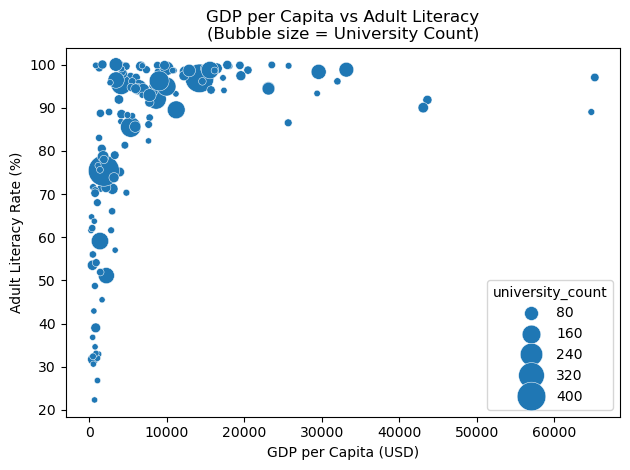

In [6]:
# plot the data
sns.scatterplot(
    data=df,
    x='gdp_per_capita',
    y='adult_rate',
    size='university_count',
    sizes=(20, 500)
)

#label the plot
plt.title('GDP per Capita vs Adult Literacy\n(Bubble size = University Count)')
plt.xlabel('GDP per Capita (USD)')
plt.ylabel('Adult Literacy Rate (%)')
plt.tight_layout()
plt.show()

This visualization shows that most countries, regardless of GDP per capita, maintain high adult literacy rates, with many clustered near 100%. However, there is a noticeable group of lower-GDP countries where the literacy is significantly below. Larger bubbles are more common among countries with both high GDP and high literacy rates.

### 2. Fertility rate vs youth literacy

This plot examines how fertility rates relate to youth literacy rates, with the bubble size indicating the number of universities.

In [7]:
# read data
with sqlite3.connect(db_path) as conn:
    df = pd.read_sql_query(
        """
        select
        country, fertility, [Youth Rate] as youth_rate, university_count
        from country_joined
        """
        , conn
    )

# drop missing values
df = df.dropna(subset=['fertility', 'youth_rate', 'university_count'])
df.head()

,country,fertility,youth_rate,university_count
0,afghanistan,4.47,65.0,40.0
1,albania,1.62,99.2,16.0
2,algeria,3.02,93.8,29.0
4,angola,5.52,77.4,8.0
6,argentina,2.26,99.5,86.0


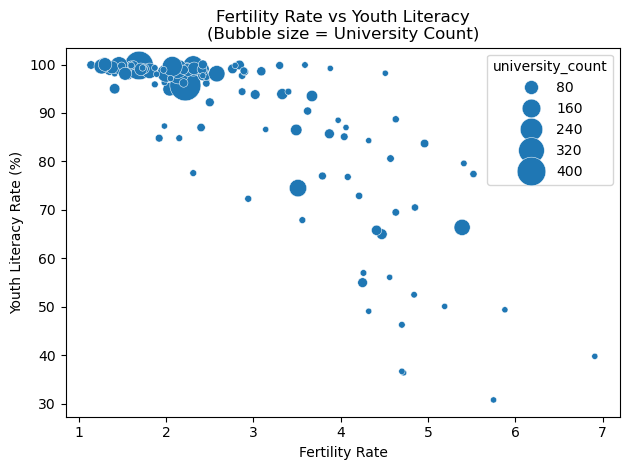

In [8]:
#plot the data
sns.scatterplot(
    data=df,
    x='fertility',
    y = 'youth_rate',
    size='university_count',
    sizes=(20,500)
)

plt.title('Fertility Rate vs Youth Literacy\n(Bubble size = University Count)')
plt.xlabel('Fertility Rate')
plt.ylabel('Youth Literacy Rate (%)')
plt.tight_layout()
plt.show()

This visualization reveals a general trend where countries with higher fertility rates tend to have lower youth literacy rates, while countries with low fertility rates generally achieve near universal literacy.

### 3. Life expectancy vs adult literacy

This plot visualizes the relationship between life expectancy and adult literacy, with bubble size representing the number of universities and color representing GDP per capita.

In [9]:
with sqlite3.connect(db_path) as conn:
    df = pd.read_sql_query(
        """
        select
        country, life_exp, [Adult Rate] as adult_rate, gdp_per_capita, university_count
        from country_joined
        """, conn
    )

#clean the data
df = df.dropna(subset=['life_exp', 'adult_rate', 'gdp_per_capita', 'university_count'])
df.head()

,country,life_exp,adult_rate,gdp_per_capita,university_count
0,afghanistan,64.5,31.7,502.115487,40.0
1,albania,78.5,97.2,5352.857411,16.0
2,algeria,76.7,75.1,3948.343279,29.0
4,angola,60.8,66.0,2973.591160,8.0
6,argentina,76.5,99.1,10006.148974,86.0


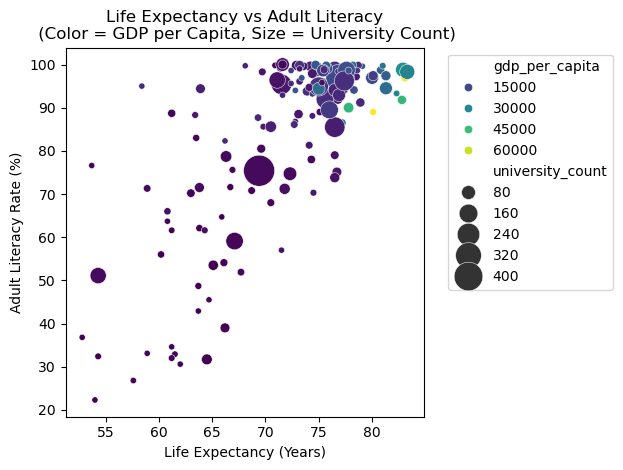

In [10]:
sns.scatterplot(
    data=df,
    x='life_exp',
    y='adult_rate',
    size='university_count',
    sizes=(20, 500),
    hue='gdp_per_capita',
    palette='viridis'
)

plt.title('Life Expectancy vs Adult Literacy\n (Color = GDP per Capita, Size = University Count)')
plt.xlabel('Life Expectancy (Years)')
plt.ylabel('Adult Literacy Rate (%)')

#move the legend outside the plot
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

This shows that countries with higher life expectancy generally also have higher adult literacy rates, with most clustering in the upper right corner. Larger bubbles tend to appear among these high life expectancy and high literacy countries. The color gradient indicates that many of these countries also have higher income levels.

### 5. University density per million people vs adult literacy

This scatter plot compares how many universities a country has per million residents with its adult literacy rate. It highlights whether higher education availability is associated with better literacy outcomes.

In [11]:
#using countries and literacy tables
with sqlite3.connect(db_path) as conn:
    df = pd.read_sql_query(
        """
        SELECT
            c.country,
            (CAST(u.university_count AS FLOAT) / (c.population / 1000000.0)) AS univ_per_million,
            l.[Adult Rate] AS adult_rate
        FROM countries AS c
        LEFT JOIN universities AS u
            ON c.country = u.country
        LEFT JOIN literacy AS l
            ON c.country = l.Country
        """,
        conn
    )

#clean
df = df.dropna(subset=['univ_per_million', 'adult_rate'])
df.head()

,country,univ_per_million,adult_rate
0,afghanistan,1.051476,31.7
1,albania,5.605792,97.2
2,algeria,0.673588,75.1
4,angola,0.251372,66.0
6,argentina,1.913718,99.1


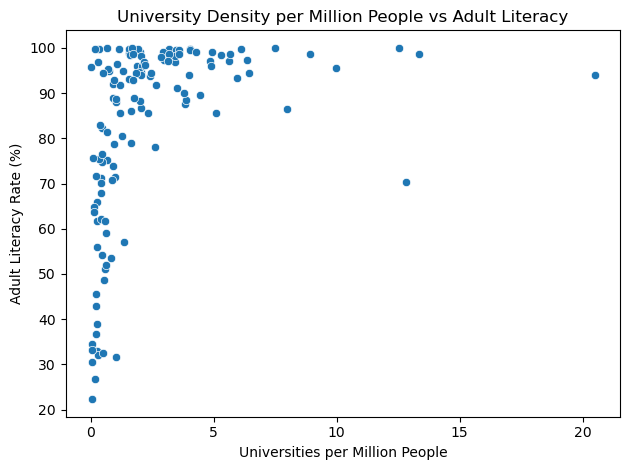

In [12]:
sns.scatterplot(
    data=df,
    x='univ_per_million',
    y='adult_rate'
)

plt.title('University Density per Million People vs Adult Literacy')
plt.xlabel('Universities per Million People')
plt.ylabel('Adult Literacy Rate (%)')
plt.tight_layout()
plt.show()

THis plot shows that most countries have relatively few universities per million people, yet many still achieve high adult literacy rates. A small number of countries with higher univeristy density also maintain very high literacy.

### 5. Top 15 countries by university count with literacy overlay

This bar chart ranks top 15 countries by total university count, with bat colors representing adult literacy rates. it lets use see whether the countries with the most high education institutions also have high literacy

In [13]:
# using universities and literacy tables
with sqlite3.connect(db_path) as conn:
    df = pd.read_sql_query(
        """
        SELECT
            u.country,
            u.university_count,
            l.[Adult Rate] AS adult_rate
        FROM universities AS u
        LEFT JOIN literacy AS l
            ON u.country = l.Country
        """,
        conn
    )

#clean and sort to select top 15
df = df.dropna(subset=['university_count', 'adult_rate'])
df = df.sort_values('university_count', ascending=False).head(15)
df.head()

,country,university_count,adult_rate
83,india,473,75.4
37,china,397,96.8
85,iran,193,85.5
84,indonesia,192,95.4
24,brazil,190,92.0


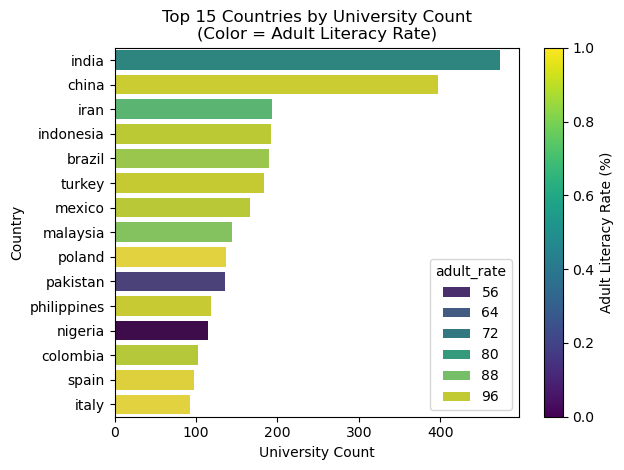

In [14]:
sns.barplot(
    data=df,
    x='university_count',
    y='country',
    hue='adult_rate',
    palette='viridis'
)

plt.title('Top 15 Countries by University Count\n(Color = Adult Literacy Rate)')
plt.xlabel('University Count')
plt.ylabel('Country')

#adult literacy legend
cbar = plt.colorbar(plt.cm.ScalarMappable(cmap='viridis'), ax=plt.gca())
cbar.set_label('Adult Literacy Rate (%)')
plt.tight_layout()
plt.show()

This chart shows that India and China lead significantly in the number of universities. Nigeria and Pakistan shows noticeably low literacy rates with many universities. However, these figures may be inaccurate or biased because the counts are based on the HipoLabs Universities API data, which may not comprehensively cover all institutions worldwide. A quick check against external shows that India and China has much more university counts than what is shown on the plot.